# Week 1 — Python and NumPy basics

Companion notebook of the first lecture: a guided path from Python and Jupyter fundamentals to the NumPy workflow used throughout this course, ending with a first Monte Carlo exercise.

**How to run**
- Locally: install [Anaconda](https://www.anaconda.com/download), then `jupyter lab`. One file is all you need.
- In the cloud: open it in [Google Colab](https://colab.research.google.com), or use the Binder link on the [course repository](https://github.com/liwt31/MathModel) README.
- Run cells in order with `Shift+Enter`. Cloud servers keep nothing between sessions — download the notebook with outputs if you want to keep them.

**Rule of the course**: if you are writing indices in a loop over an array, there is usually a shorter *and* faster expression.

**Note.** The exercises at the end (and on the lecture slides) are **practice for yourself**. They are **not** the graded assignments — problem sets are released separately on Blackboard, with due dates.

## 1. Python and Jupyter in 20 minutes

Python is easy to learn and, with the rise of AI, the default language of data work. Modeling does not require Python in principle — but in this course everything (examples, notebooks, assignments) uses it. We focus on **numerical** computation.

A Jupyter notebook is an interactive document made of **cells**. Each cell contains code plus its output; cells execute one at a time. Select a cell and press `Shift+Enter` to run it (or the run button in the toolbar).

Run the next cell and observe the output. To edit a cell, click inside it; add new cells with the `+` button (or press `b`); undo mistakes with `Ctrl+Z`. Explore — the notebook is a calculator.

In [1]:
1+1

2

Assign a value to a **variable** to store it for later use. Assignment produces no output; run the variable alone to retrieve its value.

In [2]:
pi = 3.1415926535

In [3]:
pi

3.1415926535

A single cell can hold several lines (press `Enter` for a new line inside the cell):

In [4]:
pi2 = pi * pi
pi2 / pi

3.1415926535

**Comments** are text statements that Python does not execute:

In [5]:
# this is a comment
# this is also a comment

When you ask Python for something it does not allow, an **exception** occurs. Exceptions are normal — read the error message, fix, rerun.

In [6]:
1 / 0

ZeroDivisionError: division by zero

Watch out: Chinese (full-width) characters cannot replace English ones. In coding, switch your input method to English:

In [7]:
3。14

SyntaxError: invalid character '。' (U+3002) (1996689795.py, line 1)

In [8]:
blablabksldjfiawejfhiuwfhjwiuefbiwoaijiegouhuaxuehahaha

NameError: name 'blablabksldjfiawejfhiuwfhjwiuefbiwoaijiegouhuaxuehahaha' is not defined

In [9]:
sin(pi)

NameError: name 'sin' is not defined

`sin` failed because Python does not know it yet. **Import** packages to unlock them — here, NumPy, the numerical library of the whole course. (If an exception puzzles you and you cannot resolve it, ask the TAs.)

In [10]:
from numpy import *

In [11]:
sin(pi)

np.float64(1.2246467991473532e-16)

A name followed by parentheses — like `sin(pi)` — is a **function call**; the values inside the parentheses are its **parameters**.

### Arrays and attributes

Why arrays? In Excel you compute on a whole column at once; arrays give Python the same power. `arange(11)` builds $[0, 1, \ldots, 10]$:

In [12]:
a = arange(11)

Many Python objects expose **attributes** through a `.` (dot):

In [13]:
a.mean()

np.float64(5.0)

Arrays add, subtract, multiply and divide **element-wise**:

In [14]:
a * a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100])

Distinguish element-wise multiplication (`a * a`, multiply one by one) from the **dot product** (`a.dot(a)`, multiply one by one *and sum*):

In [15]:
a.dot(a)

np.int64(385)

In [16]:
(a * a).sum()

np.int64(385)

Mind the parentheses above: attribute access has very high priority — `a * a.sum()` means something different.

When you need more than integers, use `linspace`. Functions can have **default arguments**: without `num`, you get 50 points; ask for 11 instead:

In [17]:
linspace(0, 10, 11)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In Jupyter, a `?` after any function shows its documentation — try it: `linspace?`

**Summary.** Assignment `a = 1`, function calls `sin(a)`, attributes `a.real`; arrays `arange(10)`, `linspace(0, 10, 11)`; array arithmetic is element-wise.

## 2. Plotting figures

`matplotlib` is the standard plotting library. Inside it, the `pyplot` module builds a figure step by step — a line, then labels, then the show — and `as plt` gives it a short name. This import line appears at the top of almost every plotting script:

In [18]:
from matplotlib import pyplot as plt

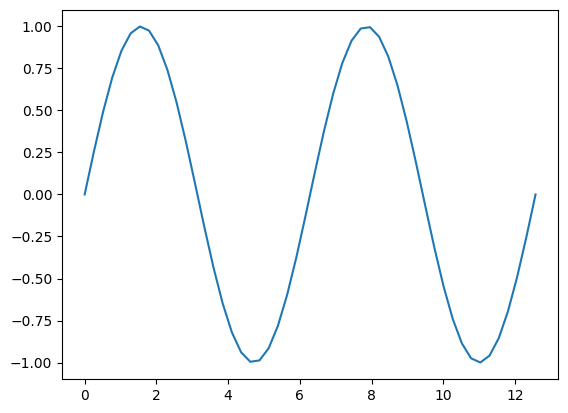

In [19]:
x = linspace(0, 4 * pi)
plt.plot(x, sin(x))
plt.show()

Many arguments customize a plot (refer to the documentation, or ask AI). One rule is non-negotiable in this course: **always label your axes** — a figure without labels and units is meaningless:

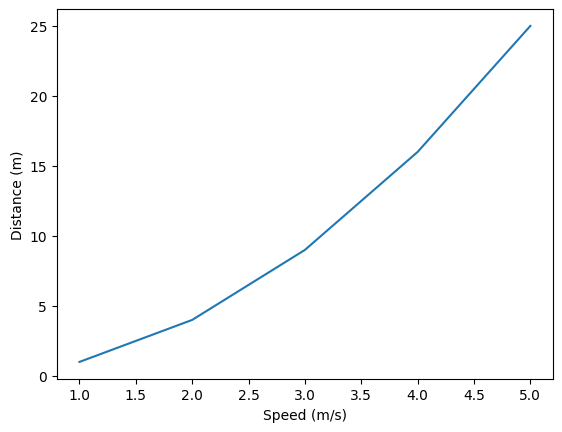

In [20]:
# braking distance vs speed
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)
plt.xlabel('Speed (m/s)')
plt.ylabel('Distance (m)')
plt.show()

A predefined style file makes figures prettier; LaTeX in the labels helps too:

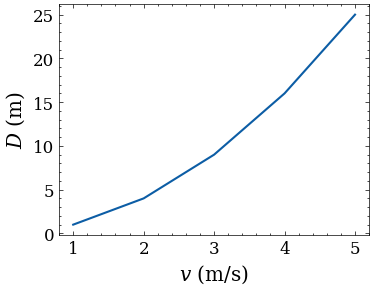

In [21]:
try:                                  # optional style file, ships with the notebook
    plt.style.use("mm.mplstyle")
except OSError:
    pass
plt.plot(x, y)
plt.xlabel('$v$ (m/s)')
plt.ylabel('$D$ (m)')
plt.show()

## 3. NumPy: shapes, broadcasting, indexing

In practice NumPy is imported with an abbreviation — `from numpy import *` pollutes the namespace and is rarely used in real code:

In [22]:
import numpy as np

**`shape` and `reshape`.** `shape` (an attribute) gives the dimensions; `reshape` (a method) rearranges the same data into higher dimensions:

In [23]:
a = np.arange(12)
print(a.shape)
a.reshape(3, 4)

(12,)


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

The correct way to multiply matrices is `.dot` or `@` — never `*`, which is element-wise:

In [24]:
(a.reshape(3, 4) @ a.reshape(4, 3)).shape

(3, 3)

Other common constructions:

In [25]:
np.array([2.4, 2024, 3.14])   # from data
np.ones((2, 3))               # all ones
np.diag(np.arange(3))         # diagonal matrix

array([[0, 0, 0],
       [0, 1, 0],
       [0, 0, 2]])

**Broadcasting.** Arrays of compatible-but-different shapes interact by stretching the smaller one (no data copied):

![broadcast](https://raw.githubusercontent.com/liwt31/MathModel/2026/fig/broadcast.png)

Broadcasting is a bit tricky at first sight but very useful. Example: the average temperature in Harbin, Beijing, Shanghai and Shenzhen is 0, 10, 20, 30 °C; low, moderate and high humidity adds 0, 1, 2 °C to the perceived temperature. Then *all* perceived temperatures are `a + b` — no loop needed.

**Indexing and slicing.** Use `[]` to extract elements:

In [26]:
a = np.linspace(0, 1, 11)
print(a[1])      # one element
print(a[1:3])    # a slice

0.1
[0.1 0.2]


In [27]:
A = np.random.random((3, 3))
print(A[0])      # the first row
print(A[0, 2])   # a single entry
print(A[:, 1])   # the second column
print(A[:2, :2]) # a 2 x 2 block

[0.46519448 0.64279459 0.30391704]
0.3039170417919551
[0.64279459 0.68376971 0.71755854]
[[0.46519448 0.64279459]
 [0.54600497 0.68376971]]


## 4. Vectorization: why arrays matter

**Vectorize**: apply one expression to a whole array instead of looping over elements. The loop still happens — but inside compiled code, so it is dramatically faster. Let us measure:

In [28]:
import time

x = np.linspace(0, 1, 10**6)      # one million points

t0 = time.perf_counter()          # the Python-loop way
s = 0.0
for v in x:
    s += v * v
t1 = time.perf_counter()
t_loop = t1 - t0

t0 = time.perf_counter()          # the NumPy way
s2 = (x**2).sum()
t1 = time.perf_counter()
t_vec = t1 - t0

print(f"loop : {t_loop:.3f} s   (sum = {s:.2f})")
print(f"vec  : {t_vec:.4f} s   (sum = {s2:.2f})")
print(f"speedup: ~{t_loop / t_vec:.0f}x  (machine-dependent)")

loop : 0.184 s   (sum = 333333.50)
vec  : 0.0033 s   (sum = 333333.50)
speedup: ~57x  (machine-dependent)


About **50× faster** on a typical laptop, and shorter to read. From now on we write **no explicit loops** whenever an array expression exists.

One more thing to learn from the arrays above: `axis`. `axis=0` reduces **down the rows** (one number per column); `axis=1` reduces **along the columns**:

In [29]:
X = np.array([[170., 60.],        # rows: persons, cols: [height, weight]
              [180., 75.],
              [160., 55.]])

mu = X.mean(axis=0)               # shape (2,): mean height, mean weight
Z = (X - mu) / X.std(axis=0)      # standardize each column (broadcasting!)

print("means :", mu)
print("Z     :", Z.round(2).tolist())
print("check : column means of Z are", Z.mean(axis=0).round(14))

means : [170.          63.33333333]
Z     : [[0.0, -0.39], [1.22, 1.37], [-1.22, -0.98]]
check : column means of Z are [ 0. -0.]


## 5. A little exercise: estimating $\pi$

**Question.** What fraction of the unit square $[0,1]^2$ lies inside the quarter circle $x^2+y^2 \le 1$? Answer: $\pi/4$. So if we throw random darts and count hits,

$$\hat\pi = 4 \times \frac{\#\text{hits}}{n}$$

estimates $\pi$. One line of NumPy — no loop over the darts.

In [30]:
rng = np.random.default_rng(42)   # reproducible randomness
n = 1_000_000
xy = rng.random((n, 2))           # n points in [0,1]^2, one call
inside = (xy**2).sum(axis=1) < 1  # boolean array: x^2 + y^2 < 1 ?
pi_hat = 4 * inside.mean()

print(f"n = {n:,}")
print(f"pi_hat = {pi_hat:.5f}   (true pi = {np.pi:.5f})")

n = 1,000,000
pi_hat = 3.14298   (true pi = 3.14159)


### Practice 1 — how fast does the error shrink?

Run the estimation for $n = 10^2, 10^3, \ldots, 10^6$ and plot the error $|\hat\pi - \pi|$ against $n$ on a log-log plot. Theory says the error scales like $1/\sqrt{n}$ — a straight line of slope $-1/2$ on log-log axes. Check it:

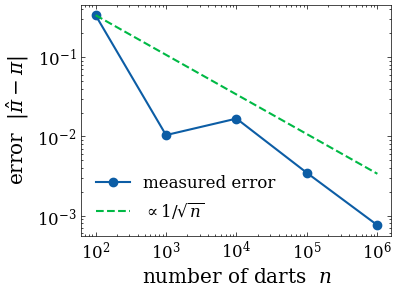

n =       100   error = 0.33841
n =     1,000   error = 0.01041
n =    10,000   error = 0.01681
n =   100,000   error = 0.00347
n = 1,000,000   error = 0.00076


In [31]:
ns = 10**np.arange(2, 7)          # 100, 1000, ..., 1_000_000
errors = []
for n in ns:
    xy = rng.random((int(n), 2))
    errors.append(abs(4 * ((xy**2).sum(axis=1) < 1).mean() - np.pi))

plt.loglog(ns, errors, "o-", label="measured error")
ref = errors[0] * (ns[0] / ns) ** 0.5
plt.loglog(ns, ref, "--", label=r"$\propto 1/\sqrt{n}$")
plt.xlabel("number of darts  $n$")
plt.ylabel(r"error  $|\hat\pi - \pi|$")
plt.legend()
plt.show()

for n, e in zip(ns, errors):
    print(f"n = {int(n):>9,}   error = {e:.5f}")

## 6. Looking ahead: a difference equation

The lecture showed the yeast model built from observations,
$p_{n+1} = p_n + 0.00082\,(655 - p_n)\,p_n$.
Here we *iterate* it — with a loop, because each step needs the previous value (vectorization pays off when the loop is over *independent* data):

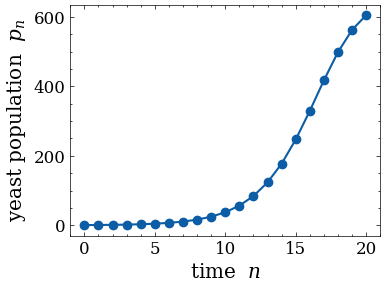

after 20 steps: p = 605.32   (equilibrium: solve 0 = 0.00082(655-p)p -> p = 655)


In [32]:
p = np.zeros(21)
p[0] = 0.529                      # initial population
for k in range(len(p) - 1):
    p[k + 1] = p[k] + 0.00082 * (655 - p[k]) * p[k]

plt.plot(range(len(p)), p, "o-")
plt.xlabel("time  $n$")
plt.ylabel("yeast population  $p_n$")
plt.show()

print(f"after 20 steps: p = {p[-1]:.2f}   (equilibrium: solve 0 = 0.00082(655-p)p -> p = 655)")

## 7. Practice exercises

**These are practice for yourself — they are not the graded assignments.** Problem sets are released separately on Blackboard, with due dates.

1. **Environment.** Run this notebook top-to-bottom. Install Anaconda locally, or use Colab/Binder.
2. **Scaling law.** In Practice 1 above: what slope do you measure on the log-log plot? Compare with $-1/2$.
3. **Speedup.** Rerun the vectorization timing with $10^6$ and $10^7$ points. Report your speedup — does it grow with $n$?
4. **Explore.** Browse past MCM/ICM problems at [contest.comap.com](https://www.contest.comap.com/undergraduate/contests/). Pick one you find interesting. In 3–5 sentences: what is asked, and which weeks of this course give you tools for it?